In [1]:
import os
os.chdir("C:/TFM/tfm_env/")

In [1]:
import torch
torch.cuda.is_available()

False

In [ ]:
# TODO: Ver cómo configurar cuda para ver si es más rápida que mi cpu
# Es una buena práctica definir el uso de gpu si se dispone, y si no, usar cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [23]:

x_tensor = torch.rand(3, 3)
# Si se dispone de gpu, esto enviará el tensor a trabajar con la gpu
gpu_tensor = x_tensor.to(device)

# Si se desea pasar de nuevo a cpu, por ejemplo porque se quiere trabajar con numpy, 
# debe utilizarse el siguiente método. No importa si ya está en cpu, no dará error: 

cpu_tensor = gpu_tensor.cpu()

cpu_tensor


tensor([[0.0219, 0.4796, 0.4429],
        [0.2521, 0.8768, 0.4084],
        [0.1585, 0.1290, 0.2584]])

In [118]:
# Train y test 

w = 0.3
bias = 0.7



torch.manual_seed(3)
X = torch.rand(50)
y = w * X + bias


# TODO: Revisar cómo hacer esto con Numpy 
# para poder seleccionar aleatoriamente la muestra
print(X.shape, y.shape)
train_split = int(0.8 * len(X))

X_train , y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]




torch.Size([50]) torch.Size([50])


In [119]:
# Para visualizar mejor los datos: 
import matplotlib.pyplot as plt

def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test,
                     test_labels=y_test, 
                     predictions=None):
    """Plots el conjunto de entrenamiento y validación y compara las preddiciones."""
    
    plt.figure(figsize=(10, 7))
    
    # Entrenamiento en azul
    plt.scatter(train_data, 
                train_labels, 
                c='blue', 
                s=4, 
                label="Conjunto de entrenamiento")
    
    
    # Testing en verde
    plt.scatter(test_data, 
                test_labels, 
                c='green', 
                s=4, 
                label="Conjunto de testing")
    
    
    if predictions is not None:
            # Testing en verde
        plt.scatter(test_data, 
                    predictions, 
                    c='red', 
                    s=4, 
                    label="Predicciones")
        
    plt.legend(prop={"size": 14})
    


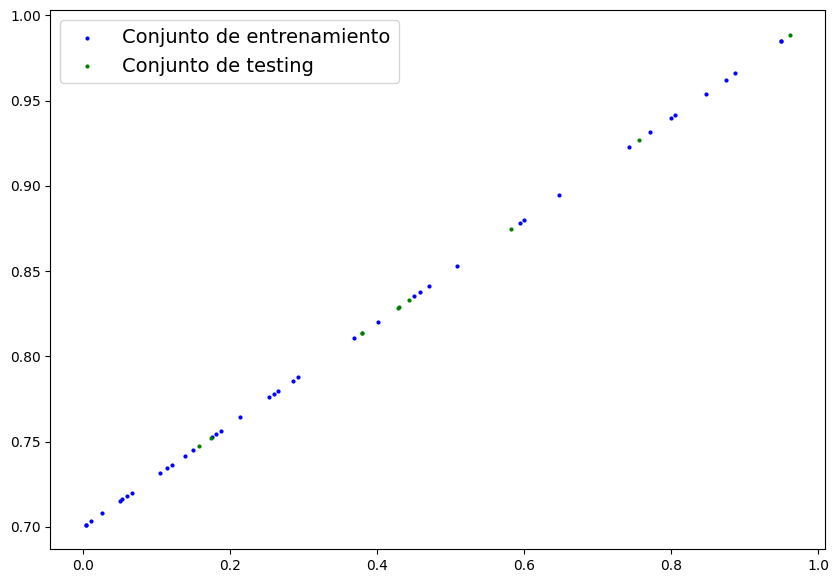

In [123]:
plot_predictions();

In [124]:
from torch import nn

class LinearRegressionModel(nn.Module): # <- casi todo en Python hereda de nn.Module
    

    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
        
        self.bias = nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
        
        
        # El método Forward define el cómputo del modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" es el input de entrada
        return self.weights * x + self.bias # this is the linear regression formula
    
    

In [204]:
torch.manual_seed(3)

lrm = LinearRegressionModel()

list(lrm.parameters())

[Parameter containing:
 tensor([0.0043], requires_grad=True),
 Parameter containing:
 tensor([0.1056], requires_grad=True)]

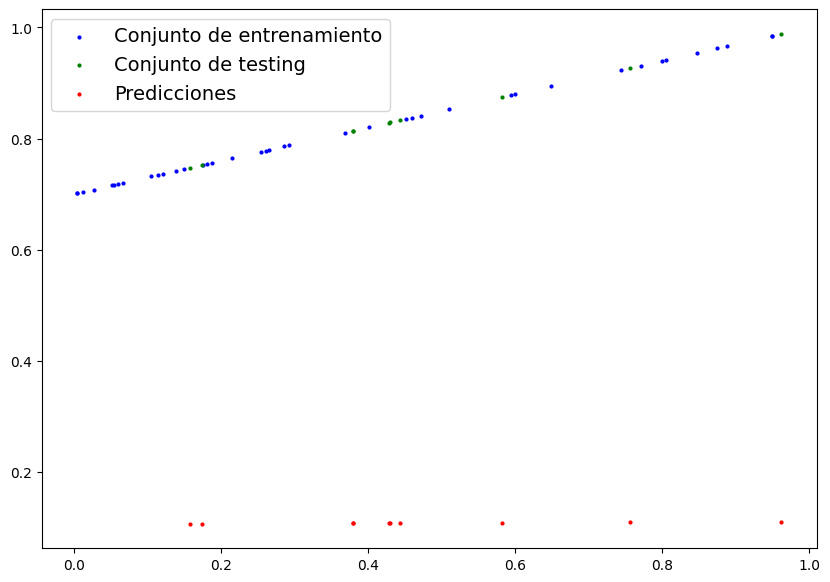

In [205]:

with torch.no_grad(): # Para gestionar el contexto también se puede usar torch.inference_mode()
    y_pred = lrm(X_test)

plot_predictions(predictions=y_pred)

In [206]:
# TODO: Revisar las funciones de pérdida, en particular una que dice 
# que es Temporal Cexionist

In [207]:
# Establecemos la función de pérdida:
loss_fn = nn.L1Loss()

# Establecemos el optimizador: (Stochastic Gradient Descent)
optimizer = torch.optim.SGD(params=lrm.parameters(),
                            lr=0.001) #Learning rate, super importante!! Entre 0 y 1. 

In [208]:
lrm.state_dict()

OrderedDict([('weights', tensor([0.0043])), ('bias', tensor([0.1056]))])

In [209]:
# Epochs: bucles sobre los datos: esto es un hiperparámetro porque lo 
# establecemos nosotros.
epochs = 10000
loss_list=[]
# 0. Bucle a través de los datos

for epoch in range(epochs):
    # Ponemos el modelo en el modo entrenamiento:
    
    lrm.train()
    # El modo entrenamiento en PyTorch pone todos los parámetros que requieren 
    # gradiente a solicitar estos gradientes. 
    
    # 1. Pasar la propagación hacia adelante
    
    y_pred = lrm(X_train)
    
    # 2. Calculamos la pérdida
    loss = loss_fn(y_pred, y_train)
    # print(f"Pérdida: {loss}")
    
    # 3. Ponemos el optimizador a gradiente cero
    optimizer.zero_grad()
    
    # 4. Realización de la propagación hacia atrás sobre la pérdida 
    # respecto a los parámetros del modelo
    loss.backward()
    
    # 5. Paso del optimizador (realización del descenso de gradiente)
    # Por defecto, cómo los cambios del optimizador se acumulan a 
    # traves del bucle, así que tenemos el cero de ellos arriba en el paso 3.
    optimizer.step() 
    
    lrm.eval()
    
    with torch.inference_mode(): #Apagamos el seguimiento de gradiente porque 
                                  # no es necesario para la evaluación del testing
        
        # 1. Hacemos la propagación hacia adelante: 
        test_pred = lrm(X_test)
        
        # 2. Calculamos la pérdida:
        test_loss = loss_fn(test_pred, y_test)
        loss_list.append(test_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
            print(lrm.state_dict())
    
    

Epoch: 0 | Loss: 0.7065309286117554 | Test loss: 0.7320904731750488
OrderedDict([('weights', tensor([0.0046])), ('bias', tensor([0.1066]))])
Epoch: 10 | Loss: 0.695094108581543 | Test loss: 0.7203108668327332
OrderedDict([('weights', tensor([0.0084])), ('bias', tensor([0.1166]))])
Epoch: 20 | Loss: 0.6836572289466858 | Test loss: 0.7085312604904175
OrderedDict([('weights', tensor([0.0122])), ('bias', tensor([0.1266]))])
Epoch: 30 | Loss: 0.6722204685211182 | Test loss: 0.6967517137527466
OrderedDict([('weights', tensor([0.0160])), ('bias', tensor([0.1366]))])
Epoch: 40 | Loss: 0.660783588886261 | Test loss: 0.6849722266197205
OrderedDict([('weights', tensor([0.0198])), ('bias', tensor([0.1466]))])
Epoch: 50 | Loss: 0.6493467092514038 | Test loss: 0.6731926202774048
OrderedDict([('weights', tensor([0.0236])), ('bias', tensor([0.1566]))])
Epoch: 60 | Loss: 0.6379098892211914 | Test loss: 0.6614130735397339
OrderedDict([('weights', tensor([0.0274])), ('bias', tensor([0.1666]))])
Epoch: 70

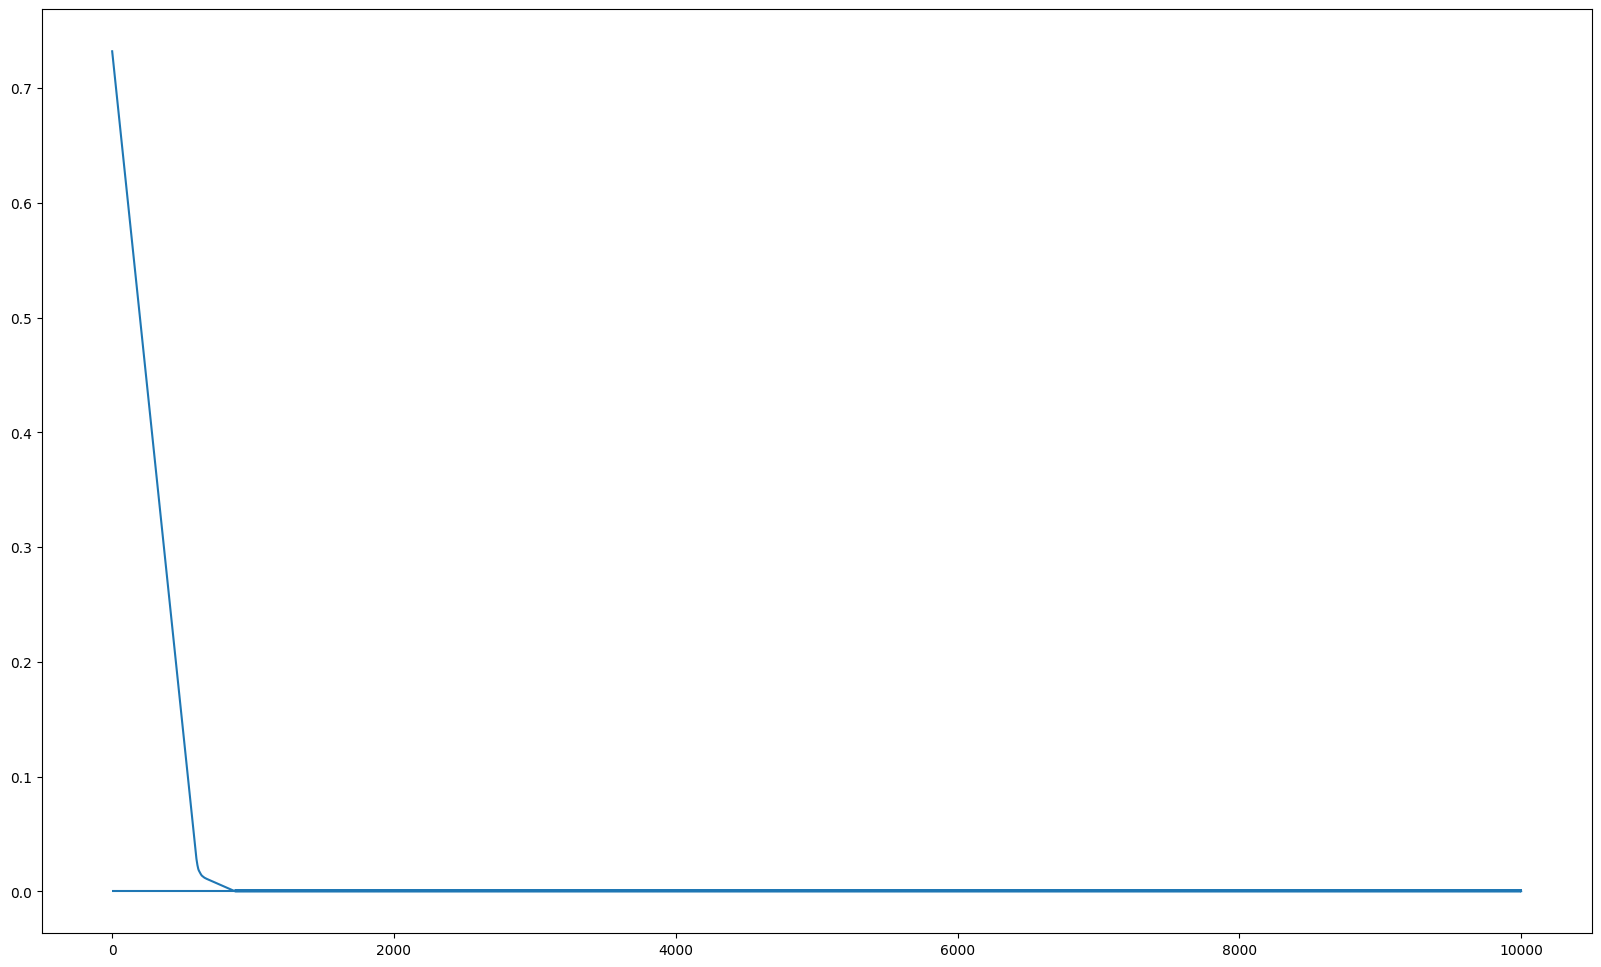

In [217]:
fig = plt.figure(figsize=(20, 12))
plt.plot(loss_list)
plt.hlines(xmin=0, xmax=len(loss_list), y=min(loss_list))

In [174]:
# Ver los parámetros del modelo, con el nombre que tienen internamente
lrm.state_dict()

OrderedDict([('weights', tensor([0.2994])), ('bias', tensor([0.7006]))])

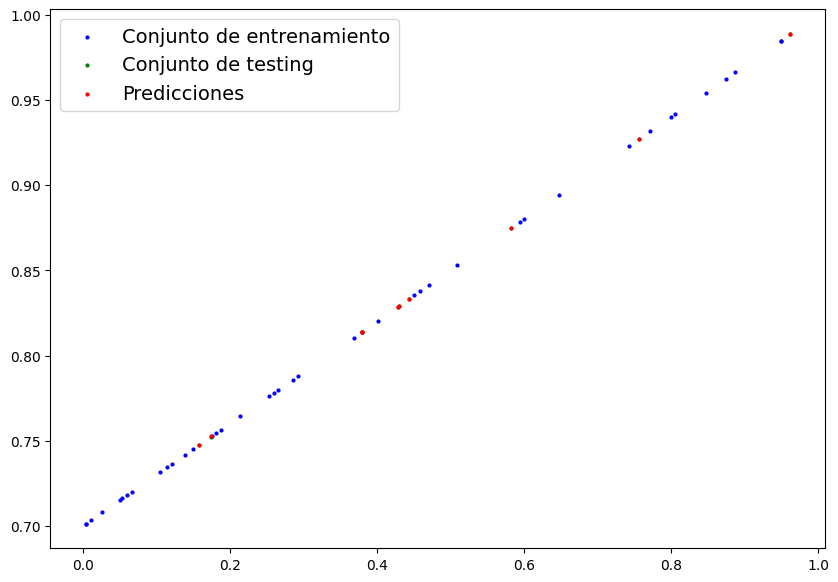

In [230]:
with torch.no_grad():
    y_pred = lrm(X_test)
    
plot_predictions(predictions=y_pred)

Hay varias opciones para guardar y cargar modelos de PyTorch.
Podemos solo guardar los pesos y bias de las neuronas o podemos cargar toda la info.

Si solo guardamos los pesos, cuando lo carguemos primero deberíamos instanciar el modelo. 
Si guardamos todo, con cargar el modelo valdría. Debemos tener en cuenta las siguientes funciones: 

1. `torch.save()` - permite guardar un objeto PyTorch en formato pickle.
2. `torch.load()` - permite cargar un objeto PyTorch guardado
3. `torch.nn.Module.load_state_dict()` permite cargar el diccionario de estados guardado de un modelo.



In [ ]:
# Hay varias opciones para guardar y cargar modelos de PyTorch.
# Podemos solo guardar los pesos y bias de las neuronas o podemos cargar toda la info.

# Si solo guardamos los pesos, cuando lo carguemos primero deberíamos instanciar el modelo. 
# Si guardamos todo, con cargar el modelo valdría. 

torch.save(lrm, "")

In [223]:
from pathlib import Path
import os
os.chdir("C:/TFM/tfm_env/")

# Creamos la carpeta.
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) # Si ya está creada, no hace nada ni lanza error.

MODULE_NAME = "lrm_prueba_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODULE_NAME

print("Saving ")
torch.save(lrm.state_dict(),  MODEL_SAVE_PATH)


Saving 


In [224]:
model = LinearRegressionModel()

In [225]:
model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [227]:
model.eval()
with torch.inference_mode():
    model_preds = model(X_test)
    
model_preds

tensor([0.8749, 0.8287, 0.8332, 0.7526, 0.9270, 0.8140, 0.7476, 0.8140, 0.8292,
        0.9888])

In [231]:
y_pred == model_preds

tensor([True, True, True, True, True, True, True, True, True, True])

# Pruebas ChatGPT

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ---- utilidades ----
def split_time_series(X, y, train_ratio=0.7, val_ratio=0.15):
    N = len(X)
    n_train = int(N * train_ratio)
    n_val = int(N * val_ratio)
    idx_train = slice(0, n_train)
    idx_val   = slice(n_train, n_train + n_val)
    idx_test  = slice(n_train + n_val, N)
    return (X[idx_train], y[idx_train]), (X[idx_val], y[idx_val]), (X[idx_test], y[idx_test])

class StandardScalerTS:
    def fit(self, x):  # x: [N, F]
        self.mean_ = x.mean(axis=0, keepdims=True)
        self.std_  = x.std(axis=0, keepdims=True) + 1e-8
        return self
    def transform(self, x):
        return (x - self.mean_) / self.std_
    def inverse_transform(self, x):
        return x * self.std_ + self.mean_

def build_supervised(features, target, lookback=60, horizon=1):
    """
    features: np.array [N, F]
    target:   np.array [N, 1]  (el valor a predecir, p.ej. precio o retorno)
    Devuelve:
      X: [N-L-H+1, L, F]
      y: [N-L-H+1, H] (si H=1 -> [N-L, 1])
    """
    X_list, y_list = [], []
    N = len(features)
    for t in range(lookback, N - horizon + 1):
        X_list.append(features[t - lookback:t])
        y_list.append(target[t:t + horizon, 0])  # vector de longitud H
    X = np.stack(X_list)                    # [M, L, F]
    y = np.stack(y_list)                    # [M, H]
    return X, y

class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]
